In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = [50, 60, 70, 80, 90]
y = [150, 180, 210, 240, 270]

print(X)
print(y)

[50, 60, 70, 80, 90]
[150, 180, 210, 240, 270]


X represents house sizes in square meters.

y represents house prices in thousands.

In [3]:
X = np.array(X)
y = np.array(y)

In [4]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X)

            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

            sse = np.sum(error**2)
            self.sse_history.append(sse)

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def calculate_mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)

In [5]:
model = LinearRegressionGD()
model.fit(X, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

theta_0: 0.04113676040970018
theta_1: 2.999435373457505


theta_0 represents the intercept in the regression equation.

theta_1 represents the slope in the regression equation.

In [6]:
pred = model.predict(70)
print(pred)

210.00161290243506


The prediction is reasonable because it is very close to 210, which matches the pattern in the dataset.

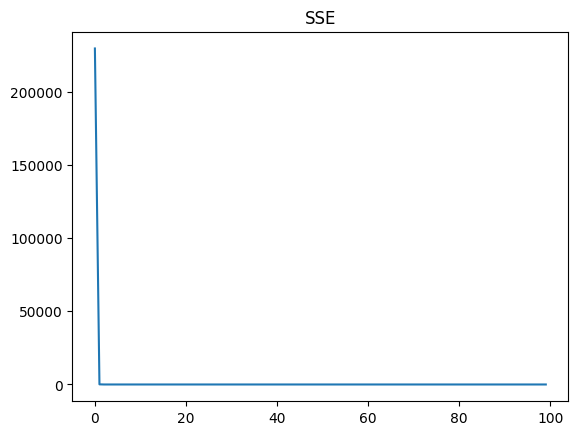

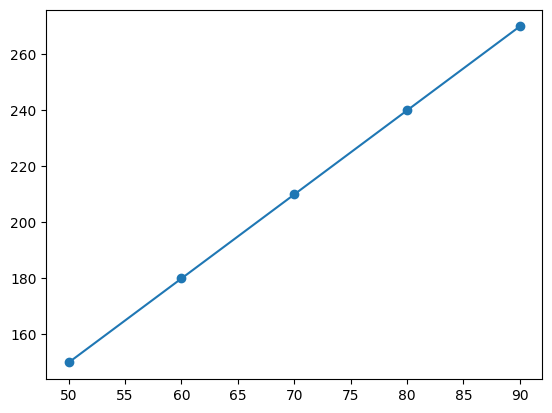

In [7]:
plt.plot(model.sse_history)
plt.title("SSE")
plt.show()

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.show()

SSE decreases over time because gradient descent updates the parameters in a way that reduces the error.

Convergence means the model is getting closer to the best values of the parameters, and the error becomes very small.

In [8]:
large_lr_model = LinearRegressionGD(learning_rate=0.01, n_iters=100)
large_lr_model.fit(X, y)

small_lr_model = LinearRegressionGD(learning_rate=0.000001, n_iters=100)
small_lr_model.fit(X, y)

print("Large learning rate final SSE:", large_lr_model.sse_history[-1])
print("Small learning rate final SSE:", small_lr_model.sse_history[-1])

Large learning rate final SSE: inf
Small learning rate final SSE: 30130.80602713573


C:\Users\DELL\AppData\Local\Temp\ipykernel_17856\935810792.py:22: RuntimeWarning: overflow encountered in square
  sse = np.sum(error**2)


With a very large learning rate, the model can overshoot and fail to converge.

With a very small learning rate, the model converges slowly.

The suitable learning rate gives faster convergence and a smaller final SSE.

In [9]:
class RidgeRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100, alpha=0.1):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.theta_0 = 0
        self.theta_1 = 0

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X) + (2 * self.alpha / n) * self.theta_1

            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X


class LassoRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100, alpha=0.1):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.theta_0 = 0
        self.theta_1 = 0

    def fit(self, X, y):
        n = len(X)

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X) + (self.alpha / n) * np.sign(self.theta_1)

            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

In [10]:
print("MSE:", model.calculate_mse(X, y))

ridge_model = RidgeRegressionGD()
ridge_model.fit(X, y)
print("Ridge prediction for 70:", ridge_model.predict(70))

lasso_model = LassoRegressionGD()
lasso_model.fit(X, y)
print("Lasso prediction for 70:", lasso_model.predict(70))

MSE: 6.636208076299688e-05
Ridge prediction for 70: 210.00079031903664
Lasso prediction for 70: 210.00147577882504


In [11]:
X_mean = np.mean(X)
X_std = np.std(X)

X_norm = (X - X_mean) / X_std

normalized_model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
normalized_model.fit(X_norm, y)

pred_norm = normalized_model.predict((70 - X_mean) / X_std)

print("Prediction after normalization:", pred_norm)

Prediction after normalization: 38.100971015430154


In [12]:
class MultiLinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            d_w = (2 / n_samples) * np.dot(X.T, error)
            d_b = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * d_w
            self.bias -= self.lr * d_b

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [13]:
X_multi = np.array([
    [50, 2],
    [60, 3],
    [70, 3],
    [80, 4],
    [90, 4]
], dtype=float)

y_multi = np.array([150, 180, 210, 240, 270], dtype=float)

X_multi_mean = np.mean(X_multi, axis=0)
X_multi_std = np.std(X_multi, axis=0)
X_multi_norm = (X_multi - X_multi_mean) / X_multi_std

multi_model = MultiLinearRegressionGD()
multi_model.fit(X_multi_norm, y_multi)

sample = np.array([[70, 3]], dtype=float)
sample_norm = (sample - X_multi_mean) / X_multi_std

print("Multiple features prediction:", multi_model.predict(sample_norm)[0])

Multiple features prediction: 208.11729125247066
